In [242]:
# Inicial Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Data Import and Inicial Exploration

In [243]:
# data import
path = Path("Data")
data = pd.read_csv(path / "cs-training.csv") 
df = data.copy()

In [244]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [245]:
# Df description before cleaning
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

# Data Preparation

### Column Unnamed: 0

In [247]:
# Column Unnamed: 0 is and index columns, we can drop it
df.drop(columns=["Unnamed: 0"], inplace=True)

## DebtRatio 


In [248]:
# # Debt ratio needs to be a value between 0 and 1, we check if there are any values above 1
# (df["DebtRatio"] > 1).value_counts()

In [249]:
# (df["DebtRatio"] < 0).value_counts()

## Age

Text(0.5, 1.0, 'Boxplot of Age')

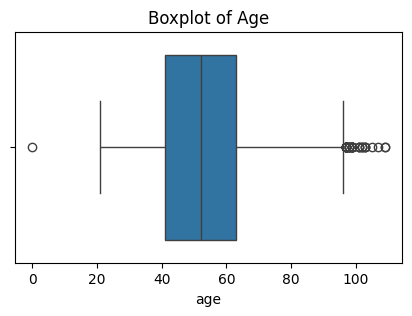

In [250]:
# Boxplot Age
plt.figure(figsize=(5,3))
sns.boxplot(x=df["age"])
plt.title("Boxplot of Age")

In [251]:
(df['age'] > 100).value_counts()


age
False    149987
True         13
Name: count, dtype: int64

In [252]:
(df['age'] < 21).value_counts()

age
False    149999
True          1
Name: count, dtype: int64

In [253]:
# There's only a few values of age that are greater than 100 and less than 18, so we can drop them without losing much information
df = df[(df['age'] >= 21) & (df['age'] <= 100)]

##  Number Of Time 30-59 and 90 Days Past Due Not Worse

In [254]:
# # Boxplots variables days past due in subplots
# dues = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfTimes90DaysLate"]

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# for i, due in enumerate(dues):
#      sns.boxplot(x=df[due], ax=axes[i])
#      axes[i].set_title(due)
# plt.tight_layout()
# plt.show()


In [255]:
# We check if the columns have some weird values
df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126006
1      16032
2       4597
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [256]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142382
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [257]:
df['NumberOfTimes90DaysLate'].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141648
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

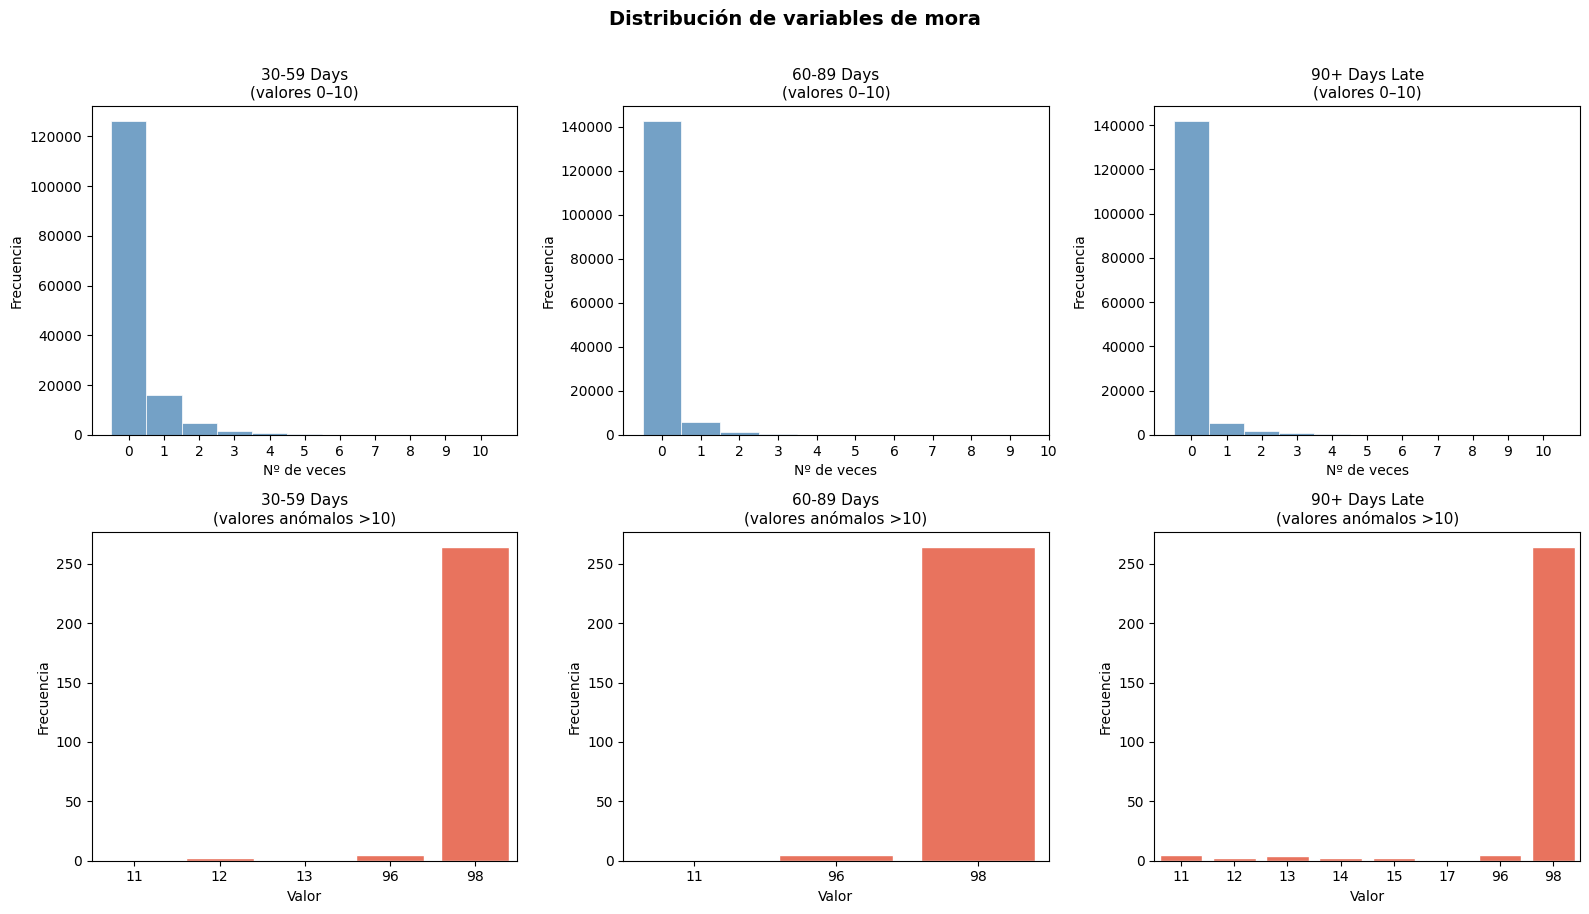

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

short_names = ['30-59 Days', '60-89 Days', '90+ Days Late']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de variables de mora', fontsize=14, fontweight='bold', y=1.01)

for i, (col, name) in enumerate(zip(cols, short_names)):

    # --- Fila 1: valores normales (0–10) ---
    normal = df[df[col] <= 10][col]
    sns.histplot(
        normal, bins=range(0, 12), ax=axes[0, i],
        discrete=True, color='steelblue', edgecolor='white', linewidth=0.5
    )
    axes[0, i].set_title(f'{name}\n(valores 0–10)', fontsize=11)
    axes[0, i].set_xlabel('Nº de veces')
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].set_xticks(range(0, 11))

    # --- Fila 2: valores anómalos (>10) ---
    anomalos = df[col][df[col] > 10].value_counts().reset_index()
    anomalos.columns = ['valor', 'frecuencia']
    anomalos = anomalos.sort_values('valor')

    sns.barplot(
        data=anomalos, x='valor', y='frecuencia',
        ax=axes[1, i], color='tomato', edgecolor='white'
    )
    axes[1, i].set_title(f'{name}\n(valores anómalos >10)', fontsize=11)
    axes[1, i].set_xlabel('Valor')
    axes[1, i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [259]:
# We see that there are some values of 96 and 98, which are not possible, so we drop them
df = df[(df['NumberOfTime30-59DaysPastDueNotWorse'] < 96) & (df['NumberOfTime60-89DaysPastDueNotWorse'] < 96) & (df['NumberOfTimes90DaysLate'] < 96)]

In [260]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
#         'NumberOfTime60-89DaysPastDueNotWorse', 
#         'NumberOfTimes90DaysLate']

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# for ax, col in zip(axes, cols):
#     # Limitar a valores <= 10 para no distorsionar (excluye los 96/98)
#     data = df[df[col] <= 10][col].value_counts().sort_index()
#     ax.bar(data.index, data.values)
#     ax.set_title(col.replace('NumberOf', ''), fontsize=10)
#     ax.set_xlabel('Nº de veces')
#     ax.set_ylabel('Frecuencia')

# plt.tight_layout()

In [261]:
# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# for i, col in enumerate(cols):
#     # Fila 1: distribución normal (valores 0-10)
#     normal = df[df[col] <= 10][col]
#     axes[0, i].hist(normal, bins=range(0, 12), edgecolor='black', align='left')
#     axes[0, i].set_title(f'{col[:15]}...\n(valores 0-10)')
    
#     # Fila 2: frecuencia de valores anómalos (96, 98)
#     anomalos = df[col].value_counts()
#     anomalos = anomalos[anomalos.index > 10]
#     axes[1, i].bar(anomalos.index.astype(str), anomalos.values, color='red', alpha=0.7)
#     axes[1, i].set_title('Valores anómalos (>10)')


# Nulls

In [262]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29603
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3890
dtype: int64

                    n_missing  pct_missing
MonthlyIncome           29603        19.77
NumberOfDependents       3890         2.60


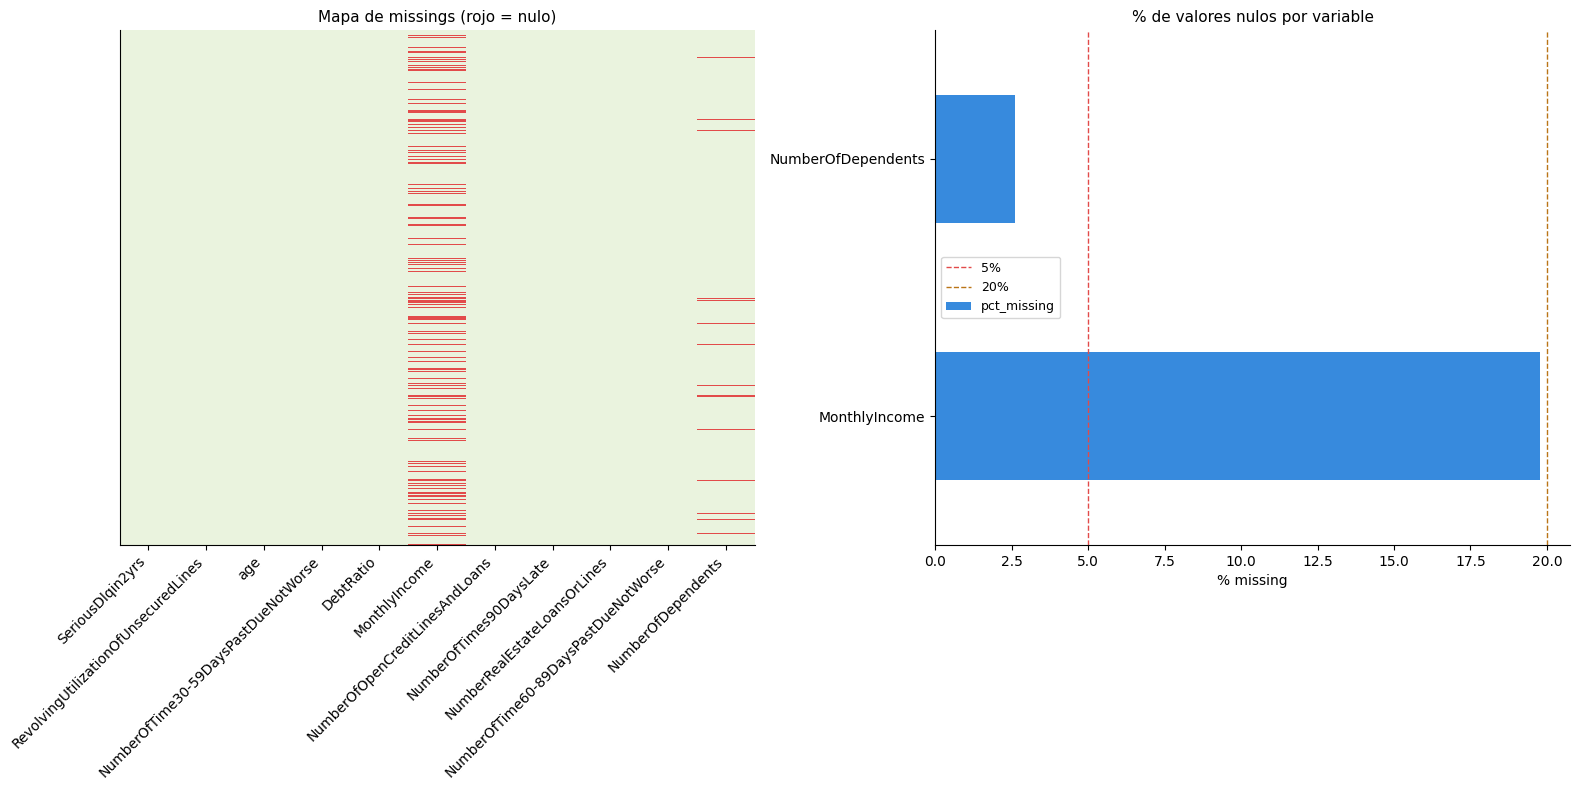

In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Resumen de missings ---
missing = pd.DataFrame({
    "n_missing":  df.isnull().sum(),
    "pct_missing": df.isnull().mean() * 100
}).query("n_missing > 0").sort_values("pct_missing", ascending=False)

print(missing.round(2))

# --- 2. Mapa de calor de missings ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=["#EAF3DE", "#E24B4A"],
    ax=axes[0]
)
axes[0].set_title("Mapa de missings (rojo = nulo)", fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
sns.despine(ax=axes[0])

# Barplot de porcentaje
missing["pct_missing"].plot(
    kind="barh",
    ax=axes[1],
    color="#378ADD",
    edgecolor="none"
)
axes[1].set_title("% de valores nulos por variable", fontsize=11)
axes[1].set_xlabel("% missing")
axes[1].axvline(5,  color="#E24B4A", linestyle="--", linewidth=1, label="5%")
axes[1].axvline(20, color="#BA7517", linestyle="--", linewidth=1, label="20%")
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# --- 3. ¿El patrón de missing está relacionado con el default? (MAR check) ---
# for col in missing.index:
#     df[f"missing_{col}"] = df[col].isnull().astype(int)

# mar_check = pd.DataFrame({
#     col: df.groupby(f"missing_{col}")["SeriousDlqin2yrs"].mean()
#     for col in missing.index
# }).T
# mar_check.columns = ["Default rate (observado)", "Default rate (missing)"]
# mar_check["diferencia"] = (
#     mar_check["Default rate (missing)"] - mar_check["Default rate (observado)"]
# ).round(4)

# print("\n--- MAR check: tasa de default por patrón de missing ---")
# print(mar_check.round(4))

# # Limpiar columnas auxiliares
# df.drop(columns=[f"missing_{col}" for col in missing.index], inplace=True)

### For Number Of Dependents we are gonna assume that every null is equal to zero

In [264]:
# Value counts of NumberOfDependents
df["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     86705
1.0     26292
2.0     19501
3.0      9479
4.0      2860
5.0       745
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

In [265]:
# Number of Dependents is gonna be filled with zeros, as it is the most common value 
df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0], inplace=True)

### Monthly Income is a bit more complex                        

In [266]:
(df["MonthlyIncome"] == 0).sum()

np.int64(1627)

In [267]:
# There are some values of MonthlyIncome that are zero, but we don't know if they are missing values or if they are actually zero
# In a model like this, it is better to consider them as missing values, as they are not likely to be zero, so we consider then as NaN
df["MonthlyIncome"].replace(0, np.nan, inplace=True)

In [268]:
# First, we create a flag for the missing values
df["MonthlyIncome_missing"] = df.MonthlyIncome.isnull().astype(int)

In [269]:
# Describe MonthlyIncome    
df.MonthlyIncome.describe()

count    1.184870e+05
mean     6.767186e+03
std      1.446993e+04
min      1.000000e+00
25%      3.500000e+03
50%      5.447000e+03
75%      8.302000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

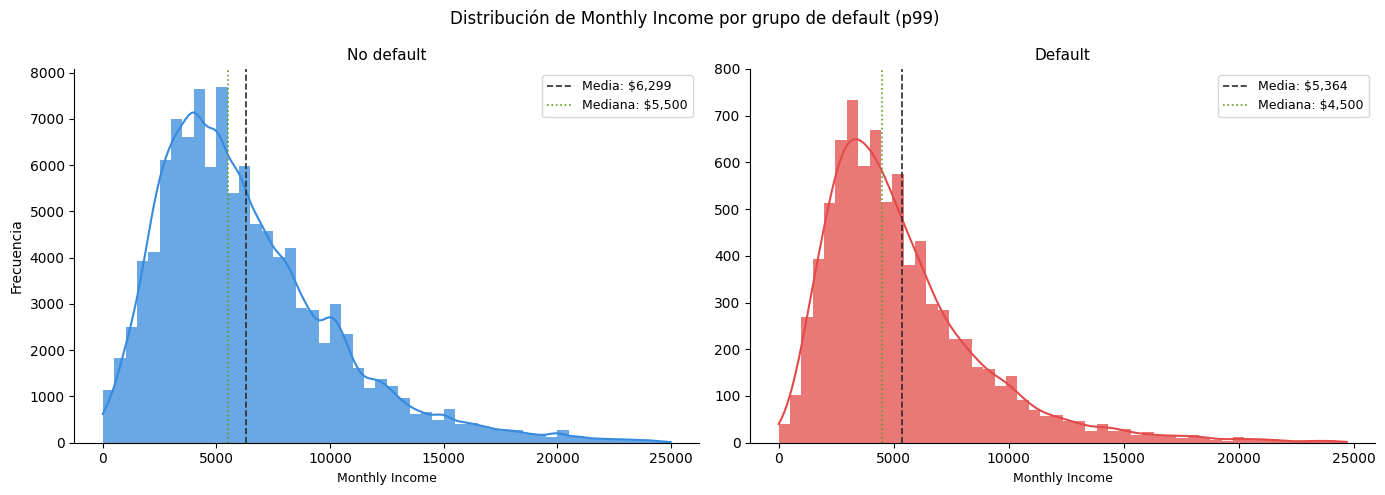

In [270]:
monthly_income_99 = df.MonthlyIncome.quantile(0.99)
df_plot = df[df.MonthlyIncome < monthly_income_99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = {0: "No default", 1: "Default"}
colors = {0: "#378ADD", 1: "#E24B4A"}

for ax, (grupo, label) in zip(axes, labels.items()):
    data = df_plot[df_plot["SeriousDlqin2yrs"] == grupo]["MonthlyIncome"]
    
    sns.histplot(
        data,
        bins=50,
        kde=True,
        color=colors[grupo],
        ax=ax,
        edgecolor="none",
        alpha=0.75,
        line_kws={"linewidth": 1.5}
    )
    ax.axvline(data.mean(),   color="#2C2C2A", linestyle="--", linewidth=1.2, label=f"Media: ${data.mean():,.0f}")
    ax.axvline(data.median(), color="#639922", linestyle=":",  linewidth=1.2, label=f"Mediana: ${data.median():,.0f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Monthly Income", fontsize=9)
    ax.set_ylabel("Frecuencia" if grupo == 0 else "")
    ax.legend(fontsize=9)
    if grupo == 1:
        ax.set_ylim(0, 800)
    sns.despine(ax=ax)

plt.suptitle("Distribución de Monthly Income por grupo de default (p99)", fontsize=12)
plt.tight_layout()
plt.show()


In [271]:
# We decide to fill the missing values of MonthlyIncome with the median, as it is a more robust measure of central tendency than the mean, and it is not affected by outliers
# df["MonthlyIncome"].fillna(df.MonthlyIncome.median(), inplace=True)

In [272]:
# monthly_income_99 = df.MonthlyIncome.quantile(0.99)
# df_monthly_income_99 = df[df.MonthlyIncome < monthly_income_99]
# sns.histplot(df_monthly_income_99.MonthlyIncome, bins=50, kde=True)

In [273]:
# We will utilize KNN imputer to fill the missing values of MonthlyIncome, as it is a more sophisticated method that takes into account the relationships between the variables, and it is not affected by outliers, as it uses the median of the neighbors to fill the missing values, instead of the mean
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_imputed = imputer.fit_transform(df)
# df_imputed = pd.DataFrame(df_imputed, columns=df.columns)
# # We check the distribution of MonthlyIncome after imputation
# monthly_income_99 = df_imputed.MonthlyIncome.quantile(0.99)
# df_monthly_income_99 = df_imputed[df_imputed.MonthlyIncome < monthly_income_99]
# sns.histplot(df_monthly_income_99.MonthlyIncome, bins=50, kde=True)

In [274]:
# # We fill the missing vallues utilizing the log of MonthlyIncome, as it is a more robust measure of central tendency than the mean, and it is not affected by outliers, as it uses the median of the neighbors to fill the missing values, instead of the mean
# df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"])
# df["MonthlyIncome_log"].fillna(df.MonthlyIncome_log.median(), inplace=True)
# # Distribution of MonthlyIncome after filling the missing values with the log of MonthlyIncome
# monthly_income_log_99 = df.MonthlyIncome_log.quantile(0.99)
# df_monthly_income_log_99 = df[df.MonthlyIncome_log < monthly_income_log_99]
# sns.histplot(df_monthly_income_log_99.MonthlyIncome_log, bins=50, kde=True)

In [275]:
# # Re-transform MonthlyIncome_log to MonthlyIncome
# df["MonthlyIncome_filled"] = np.expm1(df["MonthlyIncome_log"])
# # Distribution of MonthlyIncome after filling the missing values with the log of MonthlyIncome and re-transforming it to MonthlyIncome
# monthly_income_filled_99 = df.MonthlyIncome_filled.quantile(0.99)
# df_monthly_income_filled_99 = df[df.MonthlyIncome_filled < monthly_income_filled_99]
# sns.histplot(df_monthly_income_filled_99.MonthlyIncome_filled, bins=50, kde=True)

In [276]:
# Log-transform primero
df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"])

# Imputar con mediana por grupo de default (más preciso que mediana global)
df["MonthlyIncome_log"] = df.groupby("SeriousDlqin2yrs")["MonthlyIncome_log"]\
                            .transform(lambda x: x.fillna(x.median()))

# Verificar
print(df["MonthlyIncome_log"].isnull().sum())  # → 0
print(df.groupby("SeriousDlqin2yrs")["MonthlyIncome_log"].median().round(3))

0
SeriousDlqin2yrs
0    8.613
1    8.418
Name: MonthlyIncome_log, dtype: float64


In [277]:
# Imputation of MonthlyIncome with the log of MonthlyIncome, as it is a more robust measure of central tendency than the mean, 
# and it is not affected by outliers, as it uses the median of the neighbors to fill the missing value
# df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"]) 
# df["MonthlyIncome_log"].fillna(df.MonthlyIncome_log.median(), inplace=True)
# # Distribution of MonthlyIncome after filling the missing values with the log of MonthlyIncome
# monthly_income_log_99 = df.MonthlyIncome_log.quantile(0.99)
# df_monthly_income_log_99 = df[df.MonthlyIncome_log < monthly_income_log_99]
# sns.histplot(df_monthly_income_log_99.MonthlyIncome_log, bins=50, kde=True) 

In [278]:
# Revert   log
df["MonthlyIncome"] = np.expm1(df["MonthlyIncome_log"])

In [279]:
# df.isnull().sum()

# Outliers Detection Income

<Axes: ylabel='MonthlyIncome'>

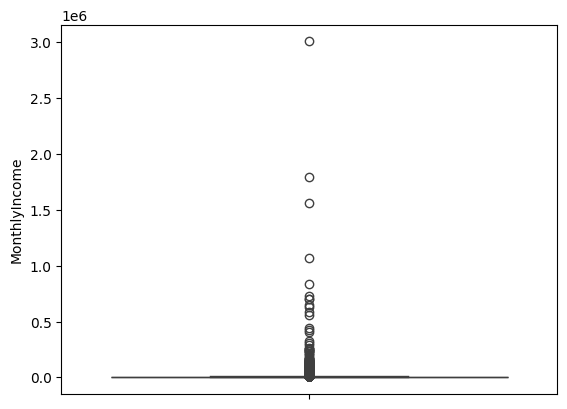

In [280]:
# We Check the outliers of Income
sns.boxplot(df.MonthlyIncome)

In [281]:
(df['MonthlyIncome'] > 500000).value_counts()

MonthlyIncome
False    149705
True         12
Name: count, dtype: int64

In [282]:
df.MonthlyIncome.quantile(0.9995)

np.float64(100000.00000000004)

In [283]:
# We create a cap variable for later
df_cap = df.copy()
df_cap = df_cap[df_cap.MonthlyIncome < df.MonthlyIncome.quantile(0.99)]

In [284]:
df_cap.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,MonthlyIncome_log
count,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000,148219.000000
mean,0.066098,5.628891,52.312430,0.245623,357.199064,6045.866077,8.436793,0.090872,1.009101,0.064992,0.732531,0.210702,8.523528
std,0.248454,210.734553,14.777385,0.697591,2049.649151,3402.251744,5.112409,0.487002,1.102447,0.330470,1.103217,0.407808,0.778773
min,0.000000,0.000000,21.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147
25%,0.000000,0.029667,41.000000,0.000000,0.178800,4000.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.294300
50%,0.000000,0.153357,52.000000,0.000000,0.370401,5500.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.612685
75%,0.000000,0.556478,63.000000,0.000000,0.889225,7244.000000,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,8.888067
max,1.000000,29110.000000,99.000000,13.000000,329664.000000,23000.000000,58.000000,17.000000,54.000000,11.000000,20.000000,1.000000,10.043293


In [285]:
df_cap.shape

(148219, 13)

In [286]:
# IQR value counts
Q1 = df_cap.MonthlyIncome.quantile(0.25)
Q3 = df_cap.MonthlyIncome.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'{(df_cap.MonthlyIncome < lower_bound).value_counts()}, {(df_cap.MonthlyIncome > upper_bound).value_counts()}')

MonthlyIncome
False    148219
Name: count, dtype: int64, MonthlyIncome
False    139202
True       9017
Name: count, dtype: int64


# Feature Engineering

In [287]:
df_clean = df.copy()
df_clean["income_per_dependent"] = df_clean["MonthlyIncome"] / (df_clean["NumberOfDependents"] + 1)
df_clean["utilization_capped"] = df_clean["RevolvingUtilizationOfUnsecuredLines"].clip(0, 1)
df_clean['CreditHistoryLength'] = df_clean['age'] - 18  # Assuming credit starts at 18

# 2. Total Past Due Occurrences
df_clean['TotalPastDue'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse'] + 
    df_clean['NumberOfTime60-89DaysPastDueNotWorse'] + 
    df_clean['NumberOfTimes90DaysLate']
)

df_clean["weighted_late_score"] = (
    1 * df_clean["NumberOfTime30-59DaysPastDueNotWorse"] +
    1.5 * df_clean["NumberOfTime60-89DaysPastDueNotWorse"] +
    2.5 * df_clean["NumberOfTimes90DaysLate"])

df_clean['HasSeriousDelinquency'] = (df_clean['NumberOfTimes90DaysLate'] > 0).astype(int)


df_clean["high_utilization_flag"] = (df_clean["utilization_capped"] > 0.8).astype(int)
df_clean['AgeGroup'] = pd.cut(df_clean['age'], 
                               bins=[0, 25, 35, 45, 55, 65, 100],
                               labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
df_clean['IncomeGroup'] = pd.qcut(df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median()), 
                                   q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'],
                                   duplicates='drop')

# 6. Debt-to-Income Ratio Category
df_clean['DTICategory'] = pd.cut(df_clean['DebtRatio'],
                                  bins=[0, 0.36, 0.43, 1, float('inf')],
                                  labels=['Low', 'Moderate', 'High', 'Very High'], include_lowest=True)

print("✅ Feature Engineering Complete")
print(f"New features created: {len(df_clean.columns) - len(df.columns)}")
print(f"Total features: {len(df_clean.columns)}")

✅ Feature Engineering Complete
New features created: 10
Total features: 23


In [288]:
# Statistical summary
print("📊 Statistical Summary:")
df_clean.describe()

📊 Statistical Summary:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing,MonthlyIncome_log,income_per_dependent,utilization_capped,CreditHistoryLength,TotalPastDue,weighted_late_score,HasSeriousDelinquency,high_utilization_flag
count,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,1.497170e+05,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,1.497170e+05,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000,149717.000000
mean,0.065978,6.058057,52.323524,0.245797,353.626931,6.491994e+03,8.468096,0.090464,1.020125,0.064829,0.738199,0.208594,8.543630,4.646182e+03,0.317985,34.323524,0.401090,0.569201,0.053895,0.166060
std,0.248244,249.991210,14.747223,0.697792,2039.678899,1.288413e+04,5.138154,0.485549,1.129976,0.330088,1.107402,0.406305,0.802139,7.970173e+03,0.348600,14.747223,1.102184,1.772189,0.225811,0.372136
min,0.000000,0.000000,21.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,1.666667e-01,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029776,41.000000,0.000000,0.176008,4.000000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.294300,2.201000e+03,0.029776,23.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.153496,52.000000,0.000000,0.367118,5.500000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.612685,4.028000e+03,0.153496,34.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.555614,63.000000,0.000000,0.869710,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,8.909370,5.500000e+03,0.555614,45.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,50708.000000,99.000000,13.000000,329664.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000,1.000000,14.917036,1.794060e+06,1.000000,81.000000,19.000000,42.500000,1.000000,1.000000


In [289]:
# Save cleaned dataset
# df_clean.to_csv(path / "german_credit_cleaned.csv", index=False)

# Automatic EDA

In [290]:
# df_cap = df_cap.drop(columns=["MonthlyIncome_missing"])

In [291]:
# def plot_distributions(df, cols=None, n_cols=4, figsize_per_plot=(5, 4)):
#     """
#     Visualiza la distribución de todas las columnas de un DataFrame.
    
#     Parámetros:
#     - df: DataFrame de pandas
#     - cols: lista de columnas a visualizar (None = todas)
#     - n_cols: número de columnas en el grid
#     - figsize_per_plot: tamaño (ancho, alto) de cada subplot
#     """
#     if cols is None:
#         cols = df.columns.tolist()

#     n_rows = -(-len(cols) // n_cols)  # ceil division
#     fig_w = figsize_per_plot[0] * n_cols
#     fig_h = figsize_per_plot[1] * n_rows

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
#     axes = axes.flatten()

#     for i, col in enumerate(cols):
#         ax = axes[i]
#         data = df[col].dropna()

#         if pd.api.types.is_numeric_dtype(data):
#             sns.histplot(data, kde=True, ax=ax, color="steelblue", edgecolor="white")
#             ax.set_title(col, fontsize=12, fontweight="bold")
#             ax.set_xlabel("")

#         else:
#             order = data.value_counts().index[:15]  # top 15 categorías
#             sns.countplot(y=data, order=order, ax=ax, color="steelblue")
#             ax.set_title(col, fontsize=12, fontweight="bold")
#             ax.set_ylabel("")

#     # Ocultar subplots vacíos
#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     plt.suptitle("Distribuciones del DataFrame", fontsize=14, fontweight="bold", y=1.01)
#     plt.tight_layout()
#     plt.show()

# plot_distributions(df_cap)

In [292]:
# # Automatic eda with ydata-profiling and sweetviz
# from ydata_profiling import ProfileReport
# import sweetviz as sv
# # Ydata-profiling
# profile = ProfileReport(df_clean, title="Credit Risk Profiling Report", explorative=True)
# profile.to_notebook_iframe()

In [293]:
# Sweetviz
# report = sv.analyze(df_clean)
# report.show_notebook()

# EDA


## Correlations

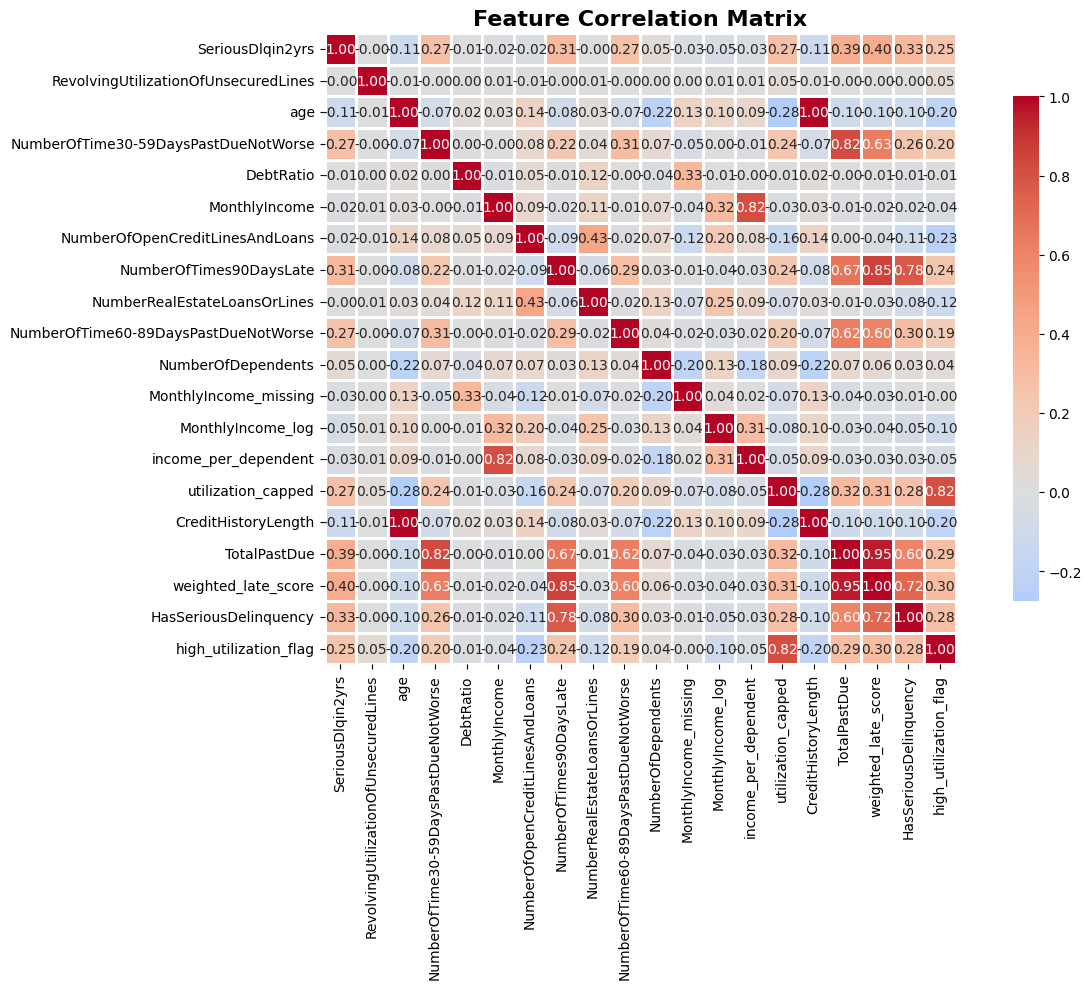


🎯 Top Correlations with Default:
weighted_late_score                     0.398456
TotalPastDue                            0.392663
HasSeriousDelinquency                   0.332751
NumberOfTimes90DaysLate                 0.314552
NumberOfTime30-59DaysPastDueNotWorse    0.274503
utilization_capped                      0.274240
NumberOfTime60-89DaysPastDueNotWorse    0.268144
high_utilization_flag                   0.253828
NumberOfDependents                      0.048328
RevolvingUtilizationOfUnsecuredLines   -0.001744
Name: SeriousDlqin2yrs, dtype: float64


In [294]:
# Correlation Analysis
fig, ax = plt.subplots(figsize=(14, 10))

# Select numeric columns only
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations with target
target_corr = correlation_matrix['SeriousDlqin2yrs'].sort_values(ascending=False)
print("\n🎯 Top Correlations with Default:")
print(target_corr[1:11])  # Exclude target itself

In [295]:
# Non-linear relationships with dcor
import dcor
print("\n🔍 Non-linear Correlations with Default:")

# Compute non-linear correlations for all numeric features
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
target = df_clean['SeriousDlqin2yrs']

dcor_results = []
for col in numeric_cols:
    if col != 'SeriousDlqin2yrs':
        dcor_val = dcor.distance_correlation(df_clean[col], target)
        dcor_results.append((col, dcor_val))

# Sort by correlation value (descending)
dcor_results.sort(key=lambda x: x[1], reverse=True)

# Display top non-linear correlations
print("Top Non-linear Correlations:")
for col, corr in dcor_results[:10]:
    print(f"{col}: {corr:.4f}")


🔍 Non-linear Correlations with Default:
Top Non-linear Correlations:
weighted_late_score: 0.4030
TotalPastDue: 0.3791
NumberOfTimes90DaysLate: 0.3423
HasSeriousDelinquency: 0.3328
NumberOfTime60-89DaysPastDueNotWorse: 0.2729
utilization_capped: 0.2694
NumberOfTime30-59DaysPastDueNotWorse: 0.2651
high_utilization_flag: 0.2538
age: 0.1117
CreditHistoryLength: 0.1117


## Likehood of Default

In [296]:
## Mean and median Default rate in general
default_rate = df_clean['SeriousDlqin2yrs'].mean()
print(f"Default Rate (Mean): {default_rate:.4f}")

Default Rate (Mean): 0.0660


In [297]:
# Confidence intervals for default rate
import statsmodels.api as sm
# Calculate confidence interval for the default rate
conf_int = sm.stats.proportion_confint(count=df_clean['SeriousDlqin2yrs'].sum(), 
                                        nobs=len(df_clean), 
                                        alpha=0.05, 
                                        method='wilson')
print(f"95% Confidence Interval for Default Rate: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")

95% Confidence Interval for Default Rate: [0.0647, 0.0672]


In [298]:
# Bootstrap confidence interval for default rate
from sklearn.utils import resample
# Function to calculate default rate
def calculate_default_rate(data):
    return data['SeriousDlqin2yrs'].mean()
# Bootstrap resampling
bootstrap_rates = []
n_iterations = 1000
for i in range(n_iterations):
    sample = resample(df_clean, replace=True, n_samples=len(df_clean), random_state=i)
    rate = calculate_default_rate(sample)
    bootstrap_rates.append(rate)
# Calculate 95% confidence interval from bootstrap samples
lower_bound = np.percentile(bootstrap_rates, 2.5)
upper_bound = np.percentile(bootstrap_rates, 97.5)
print(f"Bootstrap 95% Confidence Interval for Default Rate: [{lower_bound:.4f}, {upper_bound:.4f}]")

Bootstrap 95% Confidence Interval for Default Rate: [0.0647, 0.0674]


## Differences in Mean And Median between different groups

In [299]:
# Num-Variables
num_var = df_clean[["RevolvingUtilizationOfUnsecuredLines","DebtRatio", "age", "SeriousDlqin2yrs"]]

# Groupwise mean
groupwise_mean = num_var.groupby('SeriousDlqin2yrs').mean()
print("Groupwise Mean by Default Status:")
print(groupwise_mean)

Groupwise Mean by Default Status:
                  RevolvingUtilizationOfUnsecuredLines   DebtRatio        age
SeriousDlqin2yrs                                                             
0                                             6.173919  357.456638  52.766632
1                                             4.417834  299.411254  46.050618


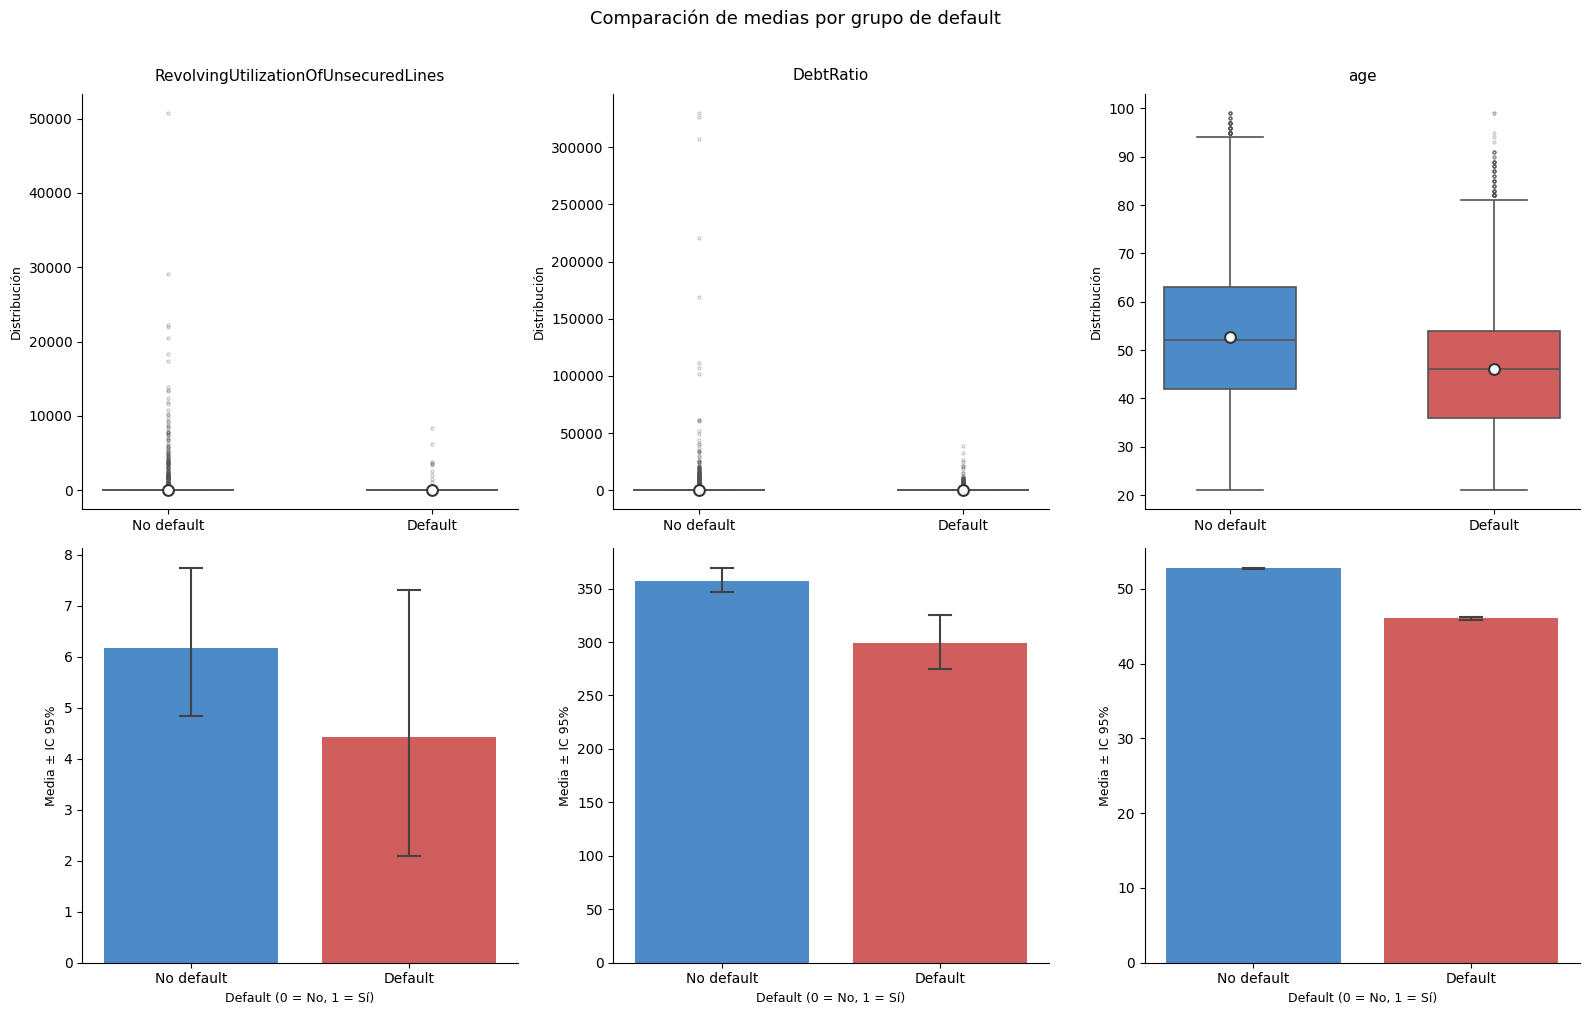

In [300]:
features = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "age"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, feat in enumerate(features):
    # --- Fila 0: Boxplot ---
    ax_box = axes[0, i]
    sns.boxplot(
        data=df_clean,
        x="SeriousDlqin2yrs",
        y=feat,
        palette={"0": "#378ADD", "1": "#E24B4A"},
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        ax=ax_box
    )
    means = df_clean.groupby("SeriousDlqin2yrs")[feat].mean()
    ax_box.scatter(means.index, means.values, color="white", zorder=5,
                   s=60, linewidths=1.5, edgecolors="#333")
    ax_box.set_title(feat, fontsize=11, pad=10)
    ax_box.set_xlabel("")
    ax_box.set_ylabel("Distribución", fontsize=9)
    ax_box.set_xticklabels(["No default", "Default"])
    sns.despine(ax=ax_box)

    # --- Fila 1: Barplot con IC 95% ---
    ax_bar = axes[1, i]
    sns.barplot(
        data=df_clean,
        x="SeriousDlqin2yrs",
        y=feat,
        palette={"0": "#378ADD", "1": "#E24B4A"},
        capsize=0.1,
        errwidth=1.5,
        ax=ax_bar
    )
    ax_bar.set_title("")
    ax_bar.set_xlabel("Default (0 = No, 1 = Sí)", fontsize=9)
    ax_bar.set_ylabel("Media ± IC 95%", fontsize=9)
    ax_bar.set_xticklabels(["No default", "Default"])
    sns.despine(ax=ax_bar)

plt.suptitle("Comparación de medias por grupo de default", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [301]:
def interpret_cliff(d):
    d = abs(d)
    if d < 0.147:  return "negligible"
    elif d < 0.330: return "pequeño"
    elif d < 0.474: return "mediano"
    else:           return "grande"

for feat in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "age"]:
    default    = df_clean.loc[df_clean["SeriousDlqin2yrs"] == 1, feat]
    no_default = df_clean.loc[df_clean["SeriousDlqin2yrs"] == 0, feat]
    
    d = pg.compute_effsize(default, no_default, eftype='CLES')
    print(f"{feat:45s} d = {d:.3f}  →  {interpret_cliff(d)}")

NameError: name 'pg' is not defined

In [ ]:
import numpy as np
import pingouin as pg
from scipy import stats

def interpret_cliff(d):
    d = abs(d)
    if d < 0.147:   return "negligible"
    elif d < 0.330: return "pequeño"
    elif d < 0.474: return "mediano"
    else:           return "grande"

def interpret_levene(p):
    return "varianzas distintas ⚠️" if p < 0.05 else "varianzas iguales ✓"

features = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "age"]

results = []

for feat in features:
    g0 = df_clean.loc[df_clean["SeriousDlqin2yrs"] == 0, feat].dropna()
    g1 = df_clean.loc[df_clean["SeriousDlqin2yrs"] == 1, feat].dropna()

    # Shapiro-Wilk (muestra máx 5000 por limitación del test)
    _, p_shap0 = stats.shapiro(g0.sample(min(5000, len(g0)), random_state=42))
    _, p_shap1 = stats.shapiro(g1.sample(min(5000, len(g1)), random_state=42))

    # Levene
    _, p_lev = stats.levene(g0, g1)

    # Mann-Whitney U (no paramétrico, apropiado dado que Shapiro fallará)
    u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')

    # Cliff's Delta
    d = pg.compute_effsize(g1, g0, eftype='CLES')

    results.append({
        "Variable":       feat,
        "Shapiro p (0)":  round(p_shap0, 4),
        "Shapiro p (1)":  round(p_shap1, 4),
        "Normalidad":     "no normal ✗" if (p_shap0 < 0.05 or p_shap1 < 0.05) else "normal ✓",
        "Levene p":       round(p_lev, 4),
        "Varianzas":      interpret_levene(p_lev),
        "Mann-Whitney p": round(p_mw, 6),
        "Sig. diferencia":  "sí ✓" if p_mw < 0.05 else "no ✗",
        "Cliff's Delta":  round(d, 3),
        "Tamaño efecto":  interpret_cliff(d),
    })

df_results = pd.DataFrame(results).set_index("Variable")
print(df_results.T.to_string())

Variable        RevolvingUtilizationOfUnsecuredLines               DebtRatio                     age
Shapiro p (0)                                    0.0                     0.0                     0.0
Shapiro p (1)                                    0.0                     0.0                     0.0
Normalidad                               no normal ✗             no normal ✗             no normal ✗
Levene p                                      0.4195                  0.0062                     0.0
Varianzas                        varianzas iguales ✓  varianzas distintas ⚠️  varianzas distintas ⚠️
Mann-Whitney p                                   0.0                     0.0                     0.0
Sig. diferencia                                 sí ✓                    sí ✓                    sí ✓
Cliff's Delta                                  0.776                   0.529                   0.366
Tamaño efecto                                 grande                  grande               

## Age and Credit Debt

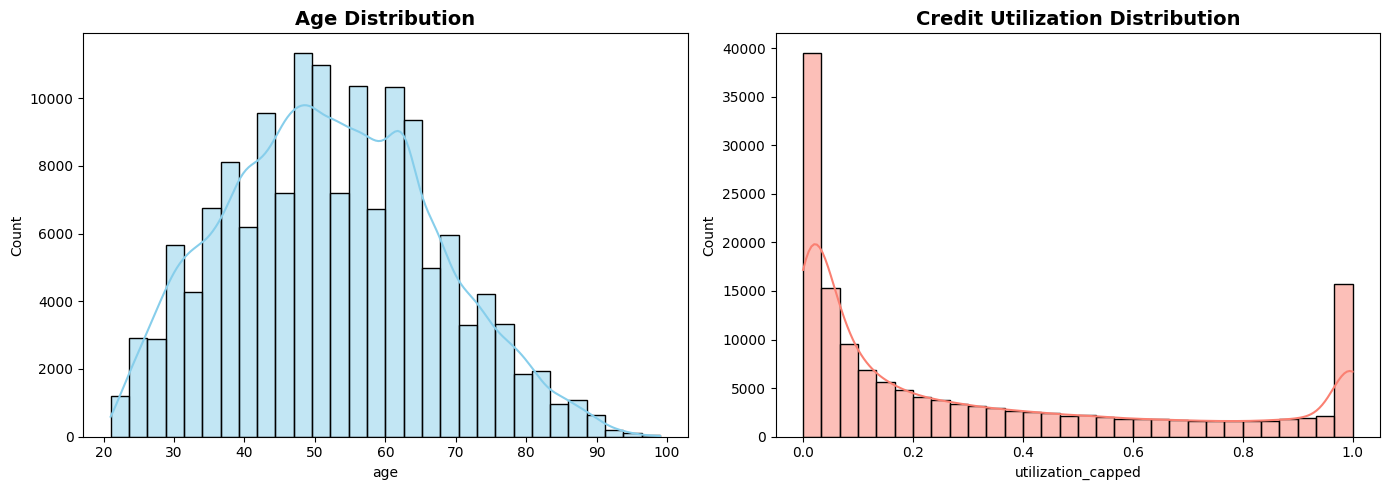

In [ ]:
# Distribution of Age and Credit Utilization
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
sns.histplot(df_clean['utilization_capped'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[1].set_title('Credit Utilization Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

In [ ]:
# Normal test for Age
from scipy.stats import shapiro
stat, p = shapiro(df_clean['age'])
print(f"Shapiro-Wilk Test for Age: stat={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("Age distribution is approximately normal.")
else:
    print("Age distribution is not normal.")

Shapiro-Wilk Test for Age: stat=0.9906, p=0.0000
Age distribution is not normal.


Text(0.5, 0, 'Age')

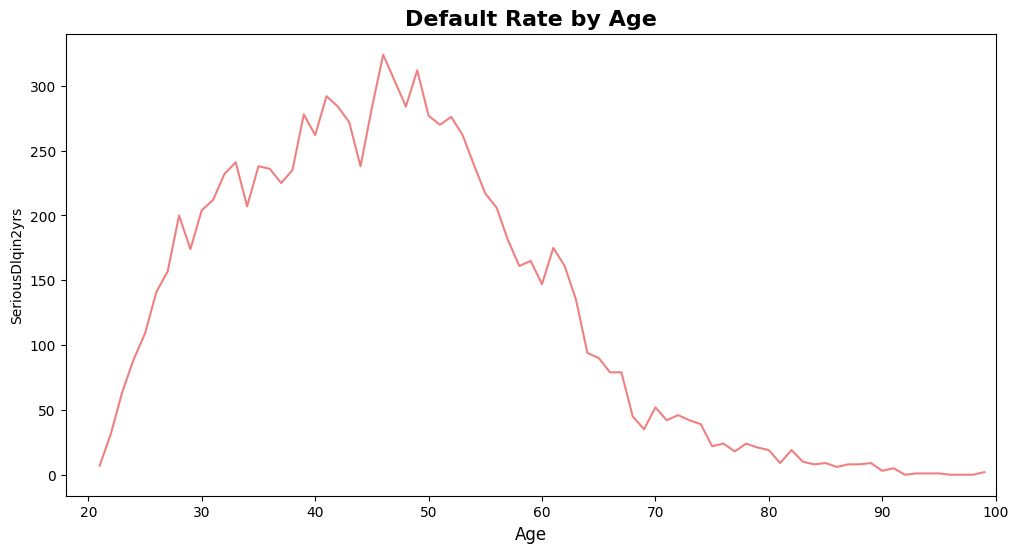

In [ ]:
# Default per Age 
# Barplot and Lineplot
age_default_rate = df_clean.groupby('age')['SeriousDlqin2yrs'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='SeriousDlqin2yrs', data=age_default_rate, color='lightcoral')
plt.title('Default Rate by Age', fontsize=16, fontweight='bold')
plt.xlim(18, 100)
plt.xlabel('Age', fontsize=12)

Text(0.5, 0, 'Age')

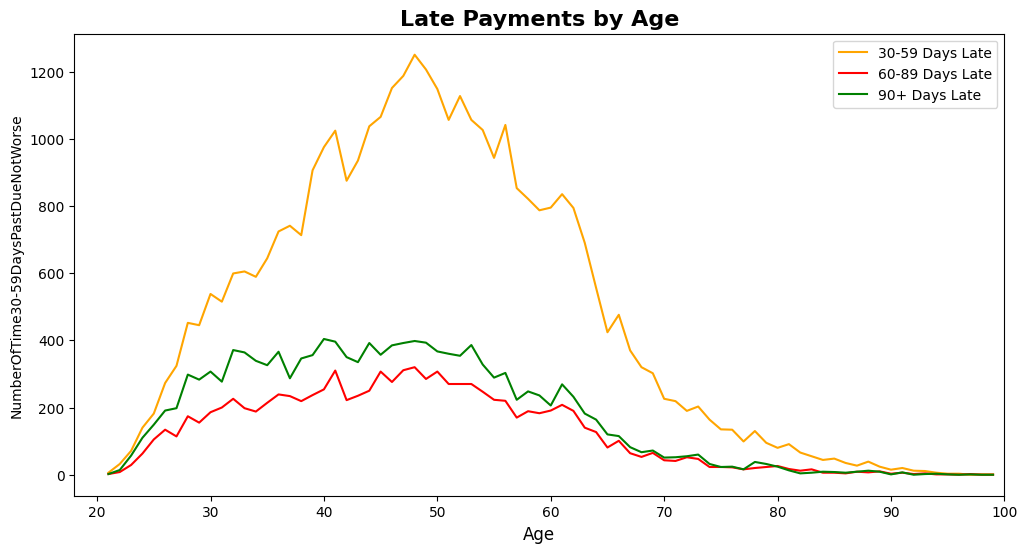

In [ ]:
# 1 month-Late and 2 months-Late
late_1 = df_clean.groupby('age')["NumberOfTime30-59DaysPastDueNotWorse"].sum().reset_index()
late_2 = df_clean.groupby('age')["NumberOfTime60-89DaysPastDueNotWorse"].sum().reset_index()
late_3 = df_clean.groupby('age')["NumberOfTimes90DaysLate"].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='age', y='NumberOfTime30-59DaysPastDueNotWorse', data=late_1, label='30-59 Days Late', color='orange')
sns.lineplot(x='age', y='NumberOfTime60-89DaysPastDueNotWorse', data=late_2, label='60-89 Days Late', color='red')
sns.lineplot(x='age', y='NumberOfTimes90DaysLate', data=late_3, label='90+ Days Late', color='green')
plt.title('Late Payments by Age', fontsize=16, fontweight='bold')
plt.xlim(18, 100)
plt.xlabel('Age', fontsize=12)

Text(0.5, 1.0, 'Default Rate by Age Group')

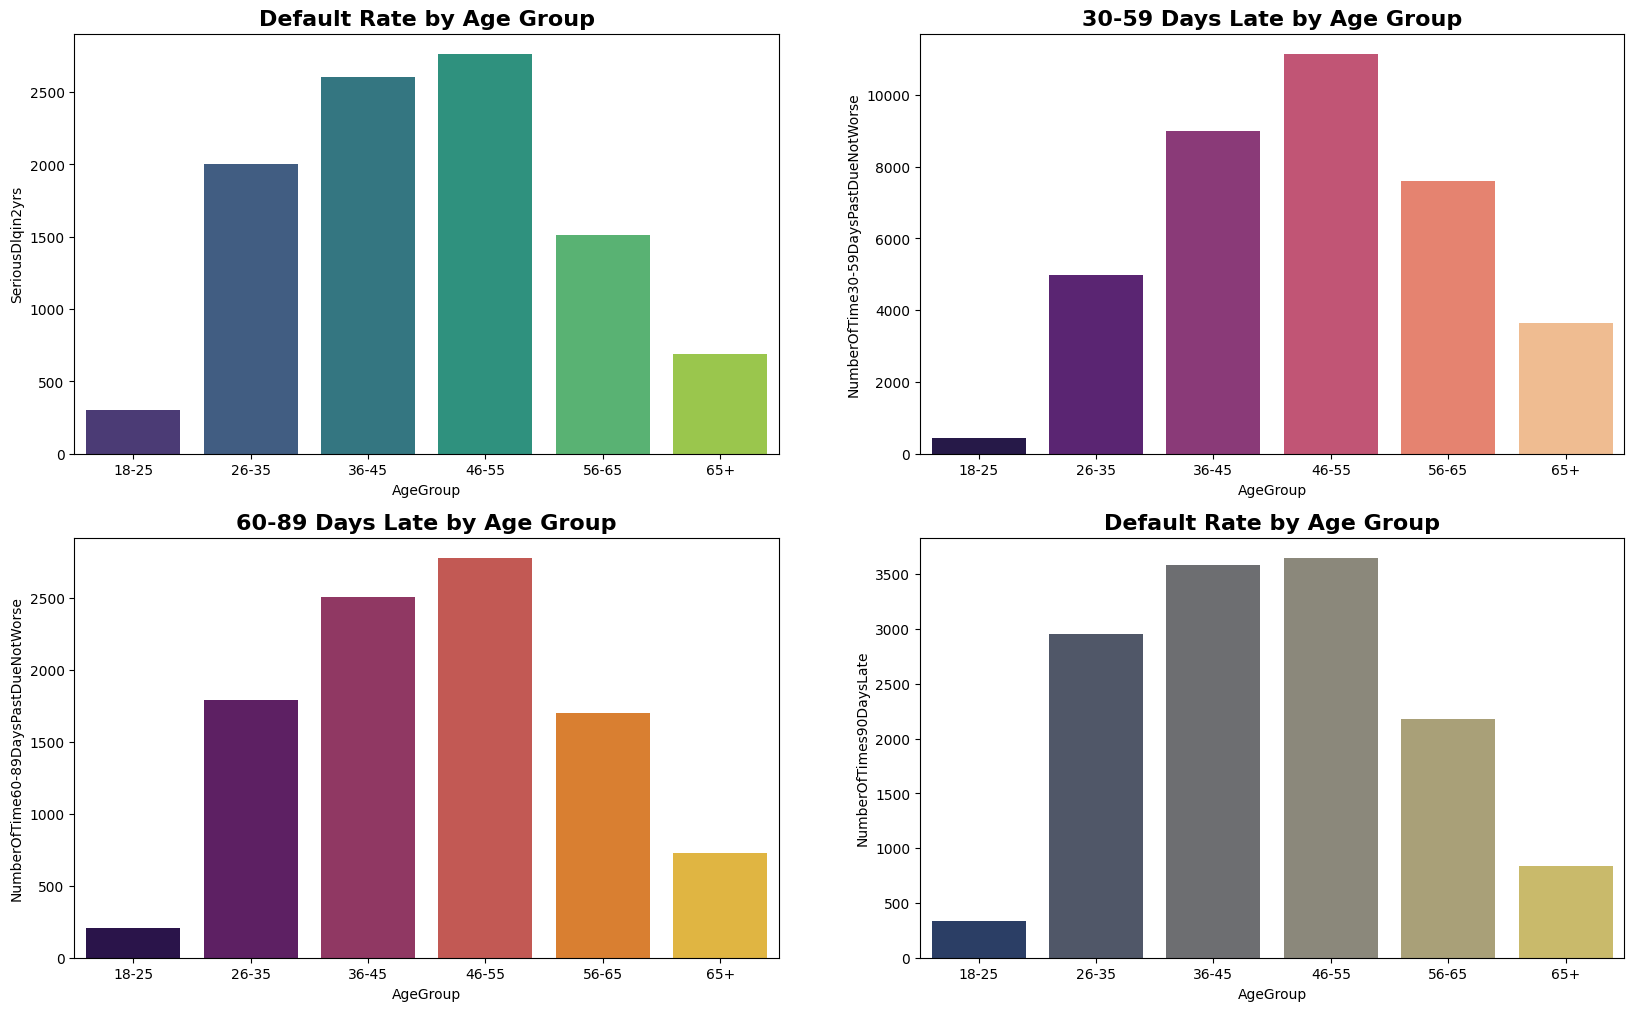

In [ ]:
# Deafult per Age Group
age_group_df = df_clean.groupby('AgeGroup')['SeriousDlqin2yrs'].sum().reset_index()
thirtydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTime30-59DaysPastDueNotWorse"].sum().reset_index()
sixtydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTime60-89DaysPastDueNotWorse"].sum().reset_index()
ninetydays_late_group_df = df_clean.groupby('AgeGroup')["NumberOfTimes90DaysLate"].sum().reset_index()
fig2, axes2 = plt.subplots(2, 2, figsize=(20, 12))
sns.barplot(x='AgeGroup', y='SeriousDlqin2yrs', data=age_group_df, palette='viridis', ax = axes2[0,0])
sns.barplot(x='AgeGroup', y='NumberOfTime30-59DaysPastDueNotWorse', data=thirtydays_late_group_df, palette='magma', ax=axes2[0, 1])
sns.barplot(x='AgeGroup', y='NumberOfTime60-89DaysPastDueNotWorse', data=sixtydays_late_group_df, palette='inferno', ax=axes2[1, 0])
sns.barplot(x='AgeGroup', y='NumberOfTimes90DaysLate', data=ninetydays_late_group_df, palette='cividis', ax=axes2[1, 1])
axes2[0,0].set_title('Default Rate by Age Group', fontsize=16, fontweight='bold')
axes2[0, 1].set_title('30-59 Days Late by Age Group', fontsize=16, fontweight='bold')
axes2[1, 0].set_title('60-89 Days Late by Age Group', fontsize=16, fontweight='bold')
axes2[1, 1].set_title('90+ Days Late by Age Group', fontsize=16, fontweight='bold')    
plt.title('Default Rate by Age Group', fontsize=16, fontweight='bold')

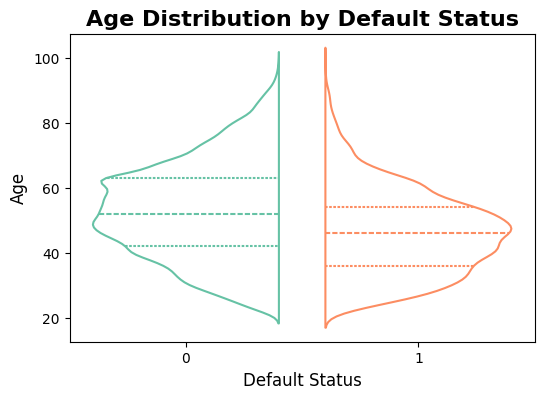

In [ ]:
# Violinplot of Age by Default
plt.figure(figsize=(6,4))
sns.violinplot(x='SeriousDlqin2yrs', y='age', data=df_clean, palette='Set2', inner='quartile', split=True, fill=False)
plt.title('Age Distribution by Default Status', fontsize=16, fontweight='bold')
plt.xlabel('Default Status', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()

## Variable Selection

In [ ]:
# Selection of features for modeling
import scorecardpy as sc

iv = sc.iv(df_clean, y='SeriousDlqin2yrs').reset_index()


In [ ]:
iv[['variable', 'info_value']].sort_values(by='info_value', ascending=False)

,variable,info_value
0,weighted_late_score,1.507895
1,TotalPastDue,1.427118
2,income_per_dependent,1.220611
3,NumberOfTimes90DaysLate,0.850477
4,MonthlyIncome,0.847427
5,MonthlyIncome_log,0.847427
6,HasSeriousDelinquency,0.808356
7,NumberOfTime30-59DaysPastDueNotWorse,0.728155
8,high_utilization_flag,0.720406
9,NumberOfTime60-89DaysPastDueNotWorse,0.567356


# Model Development


As we saw in previous sections, the class distribution of the target variable is severly unbalanced.

Text(0.5, 1.0, 'Class Distribution of Default')

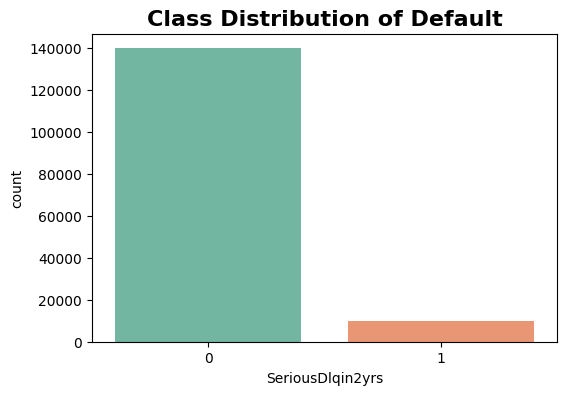

In [ ]:
# Class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='SeriousDlqin2yrs', data=df_clean, palette='Set2')
plt.title('Class Distribution of Default', fontsize=16, fontweight='bold')

In [ ]:
# Numerically %
df_clean['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316043
1     6.683957
Name: proportion, dtype: float64

Particurarly, the class consists of 93,32% of zeros and 6,68% ones.

### Logistic

In [ ]:
# First we try with modelling a simple model, logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
# Train Test Split
X = df_clean.drop(columns=['SeriousDlqin2yrs'])
X = pd.get_dummies(X, drop_first=True)
y = df_clean['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
# Logistic Model

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

c:\Users\tobal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy: 0.7879
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     28023
           1       0.19      0.71      0.31      1975

    accuracy                           0.79     29998
   macro avg       0.58      0.75      0.59     29998
weighted avg       0.92      0.79      0.84     29998

Confusion Matrix:
[[22238  5785]
 [  577  1398]]
ROC AUC Score: 0.8185


In [ ]:
# Prob predictions 50%
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_50 = (y_prob >= 0.5).astype(int)
print("Classification Report at 50% Threshold:")
print(classification_report(y_test, y_pred_50))

Classification Report at 50% Threshold:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     28023
           1       0.19      0.71      0.31      1975

    accuracy                           0.79     29998
   macro avg       0.58      0.75      0.59     29998
weighted avg       0.92      0.79      0.84     29998



In [ ]:
# Prob predictions at 30%
y_pred_30 = (y_prob >= 0.3).astype(int)
print("Classification Report at 30% Threshold:")
print(classification_report(y_test, y_pred_30))

Classification Report at 30% Threshold:
              precision    recall  f1-score   support

           0       0.99      0.45      0.61     28023
           1       0.10      0.92      0.19      1975

    accuracy                           0.48     29998
   macro avg       0.55      0.68      0.40     29998
weighted avg       0.93      0.48      0.59     29998



## XGBoost with Grid Search

In [ ]:
# XgBoost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=10, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = xgb_model.score(X_test, y_test)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print("XGBoost Classification Report:")

In [ ]:
# Grid Search CV for XgBoost
from sklearn.model_selection import GridSearchCV


In [ ]:
# Evaluation of XGBoost
print(classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
roc_auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}")

### LGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # scale_pos_weight=15
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
print("Classification Report for LGBM:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 8050, number of negative: 111938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2175
[LightGBM] [Info] Number of data points in the train set: 119988, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.067090 -> initscore=-2.632273
[LightGBM] [Info] Start training from score -2.632273
Classification Report for LGBM:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28023
           1       0.59      0.19      0.29      1975

    accuracy                           0.94     29998
   macro avg       0.77      0.59      0.63     29998
weighted avg       0.92      0.94      0.92     29998



In [ ]:
lgbm_model.score(X_test, y_test)

0.937962530835389

In [ ]:
# Params
lgbm_model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [ ]:
# Tuning parameters with Optuna
# import optuna
# optuna.logging.set_verbosity(optuna.logging.CRITICAL)
# def objective(trial):
#     params = {
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'max_depth': trial.suggest_int('max_depth', 3, 15),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
#     }
    
#     model = LGBMClassifier(**params, random_state=42, verbose=-1)
#     model.fit(X_train, y_train)
#     return model.score(X_test, y_test)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print("Best Hyperparameters:", study.best_params)

In [ ]:
# Model with best hyperparameters
# best_params = study.best_params
# lgbm_model_optuna = LGBMClassifier(**best_params, random_state=42, verbose=-1)
# lgbm_model_optuna.fit(X_train, y_train)
# y_pred_lgbm_optuna = lgbm_model_optuna.predict(X_test)
# print("Classification Report for LGBM (Optuna):")
# print(classification_report(y_test, y_pred_lgbm_optuna))

In [ ]:
# lgbm_model_optuna.score(X_test, y_test)